In [1]:
from laser_encoders import LaserEncoderPipeline
import numpy as np

/home/mnikiema/OpenSource/moore-web/.venv/lib/python3.10/site-packages/unicategories/__init__.py:41: UserWarning: Incompatible unicategories database. Please reinstall unicategories module to regenerate it.
  cache.load_from_package(__name__, 'database.pickle')


2026-02-25 15:41:13,117 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


In [4]:
from pathlib import Path

fr_path = "book-sida.fr.flat.txt"
mo_path = "book-sida.mo.flat.txt"

fr_sentences = (Path.cwd().parent / fr_path).read_text(encoding="utf-8").split("\n")
mo_sentences = (Path.cwd().parent / mo_path).read_text(encoding="utf-8").split("\n")

print(f"Read {len(fr_sentences)} French sentences from {fr_path}")
print(f"Read {len(mo_sentences)} Moore sentences from {mo_path}")

Read 280 French sentences from book-sida.fr.flat.txt
Read 248 Moore sentences from book-sida.mo.flat.txt


In [5]:
encoder = LaserEncoderPipeline(lang="mos")
fr_encoder = LaserEncoderPipeline(lang="fra")

2026-02-25 15:44:29,300 | INFO | laser_encoders.download_models |  - laser2.spm already downloaded
2026-02-25 15:44:29,361 | INFO | laser_encoders.download_models |  - laser3-mos_Latn.v1.pt already downloaded
2026-02-25 15:44:29,362 | INFO | laser_encoders.download_models |  - laser2.spm already downloaded
2026-02-25 15:44:29,362 | INFO | laser_encoders.download_models |  - laser2.cvocab already downloaded


/home/mnikiema/OpenSource/moore-web/.venv/lib/python3.10/site-packages/laser_encoders/models.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(mod

2026-02-25 15:44:32,733 | INFO | laser_encoders.download_models |  - laser2.spm already downloaded
2026-02-25 15:44:32,935 | INFO | laser_encoders.download_models |  - laser2.pt already downloaded
2026-02-25 15:44:32,938 | INFO | laser_encoders.download_models |  - laser2.spm already downloaded
2026-02-25 15:44:32,940 | INFO | laser_encoders.download_models |  - laser2.cvocab already downloaded


In [6]:
mos_embeddings = encoder.encode_sentences(mo_sentences, normalize_embeddings=True)
fr_embeddings = fr_encoder.encode_sentences(fr_sentences, normalize_embeddings=True)

/home/mnikiema/OpenSource/moore-web/.venv/lib/python3.10/site-packages/fairseq/models/transformer/transformer_encoder.py:281: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  x = torch._nested_tensor_from_mask(


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(fr_embeddings, mos_embeddings)

In [10]:
import pandas as pd

mos_fr_df = pd.DataFrame(
    similarity,
    index=[f"Fr {i}" for i in range(len(fr_sentences))],
    columns=[f"Mo {i}" for i in range(len(mo_sentences))],
)

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_heatmap(similarity_df, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity_df, annot=False, cmap="YlGnBu", cbar=True)
    plt.title(title)
    plt.show()

Text(0.5, 1.0, 'Cosine Similarity between French and Moore Sentences')

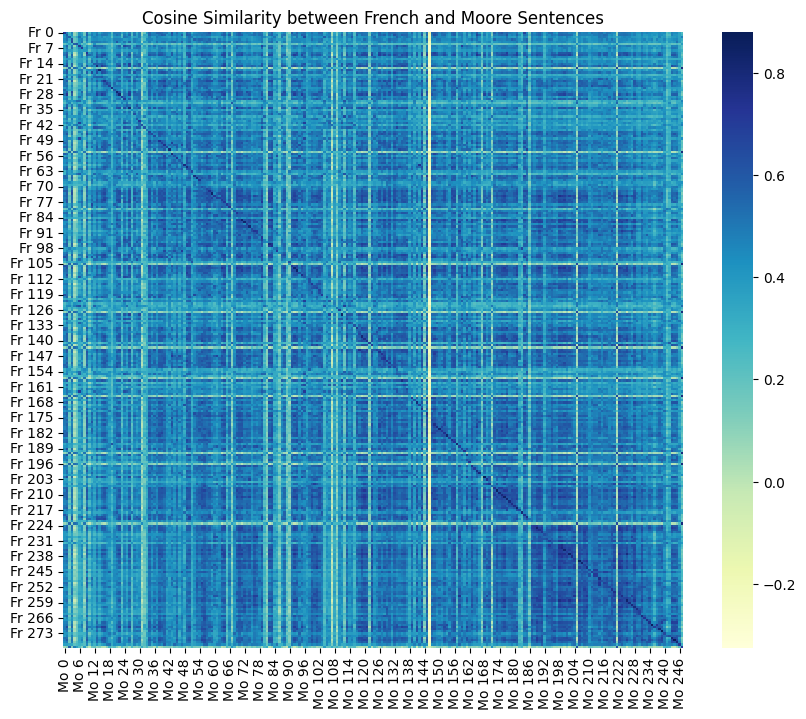

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(mos_fr_df, annot=False, cmap="YlGnBu", cbar=True)
plt.title("Cosine Similarity between French and Moore Sentences")

In [14]:
threshold = 0.7
mask = mos_fr_df < threshold
for i in range(len(mos_fr_df)):
    for j in range(len(mos_fr_df.columns)):
        if mask.iloc[i, j]:
            print(
                f"Low similarity: {mos_fr_df.index[i]} vs {mos_fr_df.columns[j]} = {mos_fr_df.iloc[i, j]:.2f}"
            )
print(mask.sum().sum())

Low similarity: Fr 0 vs Mo 1 = 0.49
Low similarity: Fr 0 vs Mo 2 = 0.27
Low similarity: Fr 0 vs Mo 3 = 0.46
Low similarity: Fr 0 vs Mo 4 = 0.08
Low similarity: Fr 0 vs Mo 5 = 0.18
Low similarity: Fr 0 vs Mo 6 = 0.42
Low similarity: Fr 0 vs Mo 7 = 0.36
Low similarity: Fr 0 vs Mo 8 = 0.16
Low similarity: Fr 0 vs Mo 9 = 0.55
Low similarity: Fr 0 vs Mo 10 = 0.28
Low similarity: Fr 0 vs Mo 11 = 0.46
Low similarity: Fr 0 vs Mo 12 = 0.41
Low similarity: Fr 0 vs Mo 13 = 0.48
Low similarity: Fr 0 vs Mo 14 = 0.36
Low similarity: Fr 0 vs Mo 15 = 0.45
Low similarity: Fr 0 vs Mo 16 = 0.49
Low similarity: Fr 0 vs Mo 17 = 0.49
Low similarity: Fr 0 vs Mo 18 = 0.45
Low similarity: Fr 0 vs Mo 19 = 0.23
Low similarity: Fr 0 vs Mo 20 = 0.49
Low similarity: Fr 0 vs Mo 21 = 0.49
Low similarity: Fr 0 vs Mo 22 = 0.49
Low similarity: Fr 0 vs Mo 23 = 0.33
Low similarity: Fr 0 vs Mo 24 = 0.45
Low similarity: Fr 0 vs Mo 25 = 0.37
Low similarity: Fr 0 vs Mo 26 = 0.49
Low similarity: Fr 0 vs Mo 27 = 0.25
Low simila

Text(0.5, 1.0, 'Cosine Similarity Heatmap: French -> Moore (Threshold > 0.7)')

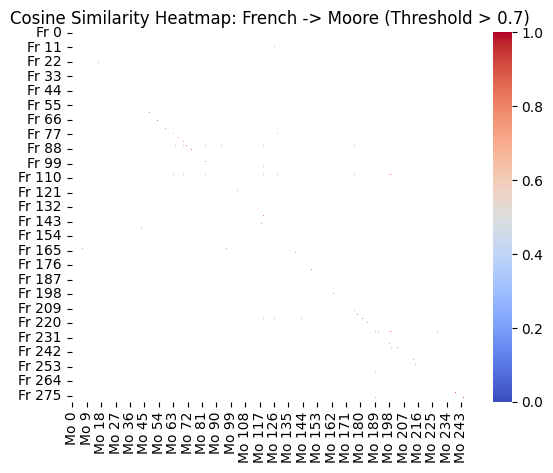

In [15]:
sns.heatmap(
    mos_fr_df,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5,
    vmin=0,
    vmax=1,
)
plt.title(f"Cosine Similarity Heatmap: French -> Moore (Threshold > {threshold})")

In [20]:
from fastdtw import fastdtw


def cosine(x, y):
    similarity = cosine_similarity(x.reshape(1, -1), y.reshape(1, -1))[0][0]
    return 1 - similarity


def dtw_align(eng_embeddings, spa_embeddings):
    alignments = []

    distance, path = fastdtw(eng_embeddings, spa_embeddings, dist=cosine)
    alignments.append(path)

    return alignments

In [21]:
fr_mos_alignments = dtw_align(fr_embeddings, mos_embeddings)

In [22]:
alignment_table = []

for fr_idx, mos_idx in fr_mos_alignments[0]:
    fr_sentence = fr_sentences[fr_idx] if fr_idx < len(fr_sentences) else ""
    mo_sentence = mo_sentences[mos_idx] if mos_idx < len(mo_sentences) else ""
    alignment_table.append((fr_sentence, mo_sentence))

bilingual_df = pd.DataFrame(alignment_table, columns=["French Sentence", "Moore Sentence"])

In [23]:
pd.set_option("display.max_colwidth", None)
html_table = bilingual_df.to_html(index=False)
with open("fr_moore_alignment.html", "w", encoding="utf-8") as f:
    f.write(html_table)

In [24]:
from IPython.display import HTML, display

display(HTML(bilingual_df.to_html(index=False)))

French Sentence,Moore Sentence
Poko était assise sous un arbre en train de lire.,"Daar a yembre, a Poko zĩi tɩɩg a yembr tẽngre n karemd a sebre."
"Sa sœur, Yembi, arrive en courant.","A yao-poaka a Yembi zoe n waa a nẽngẽ n bool-a n yeel yaa: ""Poko!"
""" Poko, Poko !",Poko!
J'ai écouté des femmes qui bavardaient.,M wʋma pagba sẽn gomd bũmb a ye yelle; b yeelame tɩ m ma solga bũmbu.
Elles ont dit que Maman a un secret.,M wʋma pagba sẽn gomd bũmb a ye yelle; b yeelame tɩ m ma solga bũmbu.
"Qu'est-ce que c'est, tu penses ?",Yaa boẽ la rẽnda?
"Qu'est-ce que c'est, tu penses ?","Fo tagsdame tɩ yaa boẽ?"""
""" "" Je crois que je sais, petite sœur "", répond Poko.","T'a Pok yeel yaa: ""Mam mii sẽn ya bũmb ninga."""
""" Allons parler avec Maman pour savoir ce que c'est vraiment.","""Wa ti ɗ tɩ gom ne m ma n bãng sẽn ya bũmb ninga sɩd sɩda."
"Courons, voyons qui arrive la première !","Wa tɩ d reng reng taab beene!"""
